<a href="https://colab.research.google.com/github/marek-milacek/MMilacek/blob/main/BellmanFord.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.4 MB/s eta 0:00:00


In [19]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# ── 1. GRAF Z OSM ──────────────────────────────────────────────────
G = ox.graph_from_place("Prague Zbraslav, Czech Republic", network_type="bike",simplify=True) # zrusim multigraf
G = ox.add_edge_speeds(G, fallback=15)
G = ox.add_edge_travel_times(G)

/usr/local/lib/python3.12/dist-packages/osmnx/routing.py:553: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  edges[["highway", "speed_kph"]].set_index("highway").iloc[:, 0].fillna(hwy_speed_avg)


Délka: 539 m,  uzlů: 2


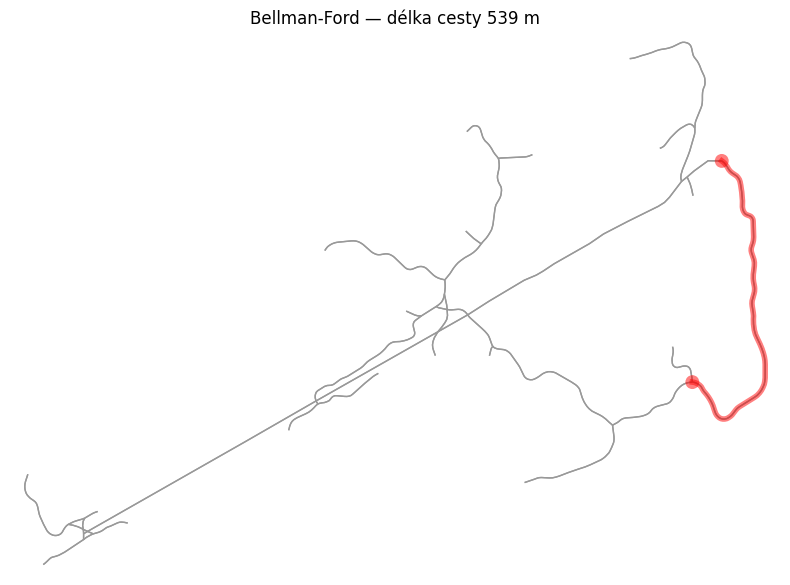

In [20]:
# ── 2. BELLMAN-FORD OD NULY ────────────────────────────────────────
def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = [(u, v, d["length"]) for u, v, d in graf.edges(data=True)]

    # Vzdálenosti — na začátku vše nekonečno
    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    # Klíčová myšlenka: opakuj (počet uzlů - 1) krát
    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:          # projdi VŠECHNY hrany
            if dist[u] + vaha < dist[v]:  # lze zlepšit?
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break                         # hotovo dřív — optimalizace

    # Rekonstrukce cesty
    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()

    return dist[cil], cesta

# ── 3. SPUŠTĚNÍ ────────────────────────────────────────────────────
start_gps = (49.9763189, 14.4025064)  # Nový začátek
cil_gps   = (49.9659056, 14.3853106)  # Nový cíl (Lidl Zbraslav)
start = ox.nearest_nodes(G, X=start_gps[1], Y=start_gps[0])
cil   = ox.nearest_nodes(G, X=cil_gps[1],   Y=cil_gps[0])

delka, cesta = bellman_ford(G, start, cil)
print(f"Délka: {delka:.0f} m,  uzlů: {len(cesta)}")

# ── 4. VIZUALIZACE ─────────────────────────────────────────────────
fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="red", route_linewidth=4,
    node_size=0, bgcolor="white",
    show=False, close=False,
)
ax.set_title(f"Bellman-Ford — délka cesty {delka:.0f} m")
plt.tight_layout()
plt.savefig("bellman_ford.png", dpi=150, bbox_inches="tight")
plt.show()

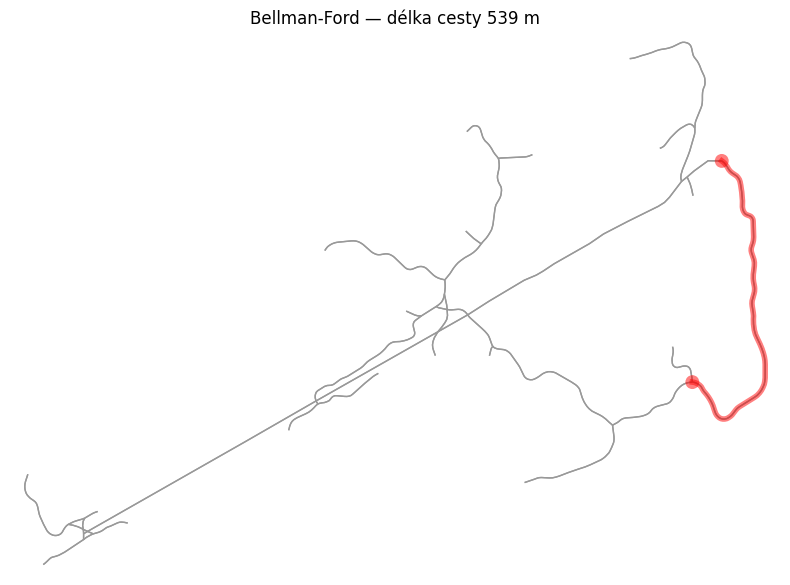

In [23]:
fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="red", route_linewidth=4,
    node_size=0, bgcolor="white",
    show=False, close=False,
)
ax.set_title(f"Bellman-Ford — délka cesty {delka:.0f} m")
plt.tight_layout()
plt.savefig("bellman_ford.png", dpi=150, bbox_inches="tight")
plt.show()

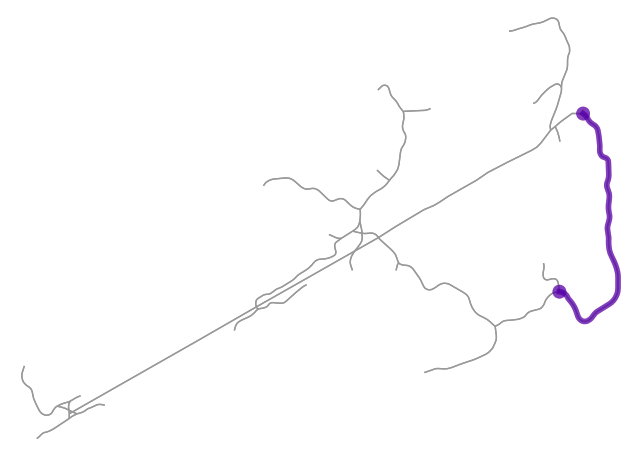

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [24]:
ox.plot_graph_routes(
    G,
    routes=[cesta_delka, cesta_cas],
    route_colors=["red", "blue"],
    route_linewidths=[4, 4],
    node_size=0,
    bgcolor="white"
)

In [25]:
import folium

body_delka = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_delka]
body_cas   = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_cas]

mid = body_delka[len(body_delka) // 2]
m = folium.Map(location=mid, zoom_start=15, width="70%")

folium.PolyLine(body_delka, color="red",  weight=4).add_to(m)
folium.PolyLine(body_cas,   color="blue", weight=4).add_to(m)

# start a cíl
folium.Marker(body_cas[0], popup="Kaufland", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(body_cas[-1], popup="Medvědi",  icon=folium.Icon(color="red")).add_to(m)

m.save("cestyZbraslav.html") # content > sample_data
m

Cesta je dlouhá 539.24 metrů.


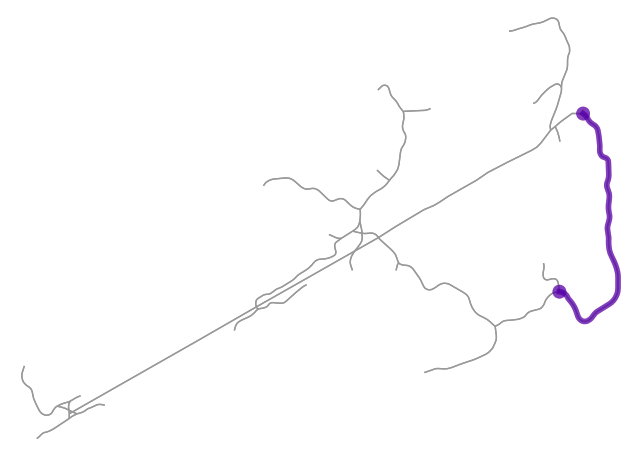

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [21]:
cesta_delka = ox.shortest_path(G, start, cil, weight='length')
cesta_cas   = ox.shortest_path(G, start, cil, weight='travel_time')
delka_cesty = nx.shortest_path_length(G, start, cil, weight='length')
print(f'Cesta je dlouhá {delka_cesty:.2f} metrů.')

ox.plot_graph_routes(
    G,
    routes=[cesta_delka, cesta_cas],
    route_colors=["red", "blue"],
    route_linewidths=[4, 4],
    node_size=0,
    bgcolor="white",

)

## Folium - Interaktivní mapa

In [22]:
import folium

body_delka = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_delka]
body_cas   = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_cas]

mid = body_delka[len(body_delka) // 2]
m = folium.Map(location=mid, zoom_start=15, width="70%")

folium.PolyLine(body_delka, color="red",  weight=4).add_to(m)
folium.PolyLine(body_cas,   color="blue", weight=4).add_to(m)

# start a cíl
folium.Marker(body_cas[0], popup="Kaufland", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(body_cas[-1], popup="Medvědi",  icon=folium.Icon(color="red")).add_to(m)

m.save("cestyZbraslav.html") # content > sample_data
m